In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, partial_dependence
import warnings
warnings.filterwarnings('ignore')

In [55]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data['time'] = pd.to_datetime(data['time'])

In [56]:
# Tree-based processed splits — unscaled, interpretable features
# Used for tasks 18 (extreme events on raw data), 19 & 20 (importance on tree features)
X_train = pd.read_csv("../../../data/processed/exp_1/X_train_tree.csv")
X_test  = pd.read_csv("../../../data/processed/exp_1/X_test_tree.csv")
y_train = pd.read_csv("../../../data/processed/exp_1/y_train.csv").squeeze("columns")
y_test  = pd.read_csv("../../../data/processed/exp_1/y_test.csv").squeeze("columns")

# y column is named 'target' (raw PM2.5 values in µg/m³)
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"y range (train): {y_train.min():.1f} – {y_train.max():.1f} µg/m³")
print(f"y range (test) : {y_test.min():.1f}  – {y_test.max():.1f} µg/m³")

X_train : (14025, 51)  |  X_test : (3506, 51)
y_train : (14025,)  |  y_test : (3506,)
y range (train): 0.6 – 124.8 µg/m³
y range (test) : 0.4  – 164.4 µg/m³


### 18. Extreme Pollution Event Analysis

In [57]:
# Define extreme events using the raw data PM2.5 series
p95 = data['pm2_5'].quantile(0.95)
p99 = data['pm2_5'].quantile(0.99)
print(f"95th percentile threshold : {p95:.2f} µg/m³")
print(f"99th percentile threshold : {p99:.2f} µg/m³")
print(f"WHO 24h guideline         : 15 µg/m³")
print(f"WHO annual guideline      : 5  µg/m³")

extreme_95 = data[data['pm2_5'] >= p95].copy()
extreme_99 = data[data['pm2_5'] >= p99].copy()
print(f"\nEvents >= P95 : {len(extreme_95)} hours  ({100*len(extreme_95)/len(data):.1f}% of dataset)")
print(f"Events >= P99 : {len(extreme_99)} hours  ({100*len(extreme_99)/len(data):.1f}% of dataset)")

95th percentile threshold : 68.00 µg/m³
99th percentile threshold : 100.40 µg/m³
WHO 24h guideline         : 15 µg/m³
WHO annual guideline      : 5  µg/m³

Events >= P95 : 879 hours  (5.0% of dataset)
Events >= P99 : 178 hours  (1.0% of dataset)


In [58]:
# Top 20 most extreme pollution spikes with context
top20 = data.nlargest(20, 'pm2_5')[[
    'time', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m'
]].reset_index(drop=True)
top20.index += 1
print("Top 20 Highest PM2.5 Readings (with meteorological context):")
print(top20.to_string())

Top 20 Highest PM2.5 Readings (with meteorological context):
                  time  pm2_5   pm10  carbon_monoxide  nitrogen_dioxide  temperature_2m  relative_humidity_2m  wind_speed_10m  wind_direction_10m
1  2024-11-26 22:00:00  164.4  172.3             1309              31.4            13.6                    95             1.6                 270
2  2024-11-26 23:00:00  162.1  170.0             1229              29.8            13.2                    95             1.8                 127
3  2024-11-27 22:00:00  161.1  172.8             1139              39.5            12.4                    86             1.1                 171
4  2024-11-26 21:00:00  159.3  167.2             1341              32.2            13.6                    92             0.9                 191
5  2024-11-27 23:00:00  158.8  170.9             1213              37.9            11.5                    91             1.8                 174
6  2024-11-27 00:00:00  157.9  166.2             1054          

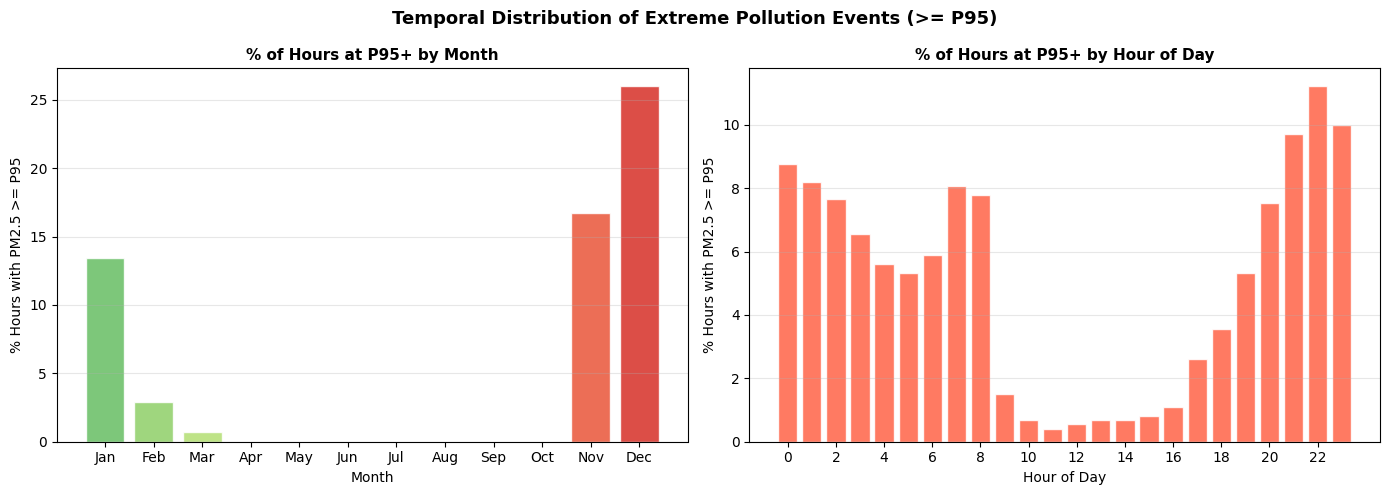

In [59]:
# Temporal distribution of extreme events: by month and hour of day
extreme_95['month'] = extreme_95['time'].dt.month
extreme_95['hour']  = extreme_95['time'].dt.hour
data['month']       = data['time'].dt.month
data['hour']        = data['time'].dt.hour

month_rate = (extreme_95.groupby('month').size() / data.groupby('month').size() * 100).fillna(0)
hour_rate  = (extreme_95.groupby('hour').size()  / data.groupby('hour').size()  * 100).fillna(0)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 13), [month_rate.get(m, 0) for m in range(1, 13)],
            color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 12)), alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('% of Hours at P95+ by Month', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% Hours with PM2.5 >= P95')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(hour_rate.index, hour_rate.values, color='tomato', alpha=0.85, edgecolor='white')
axes[1].set_title('% of Hours at P95+ by Hour of Day', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('% Hours with PM2.5 >= P95')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Temporal Distribution of Extreme Pollution Events (>= P95)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

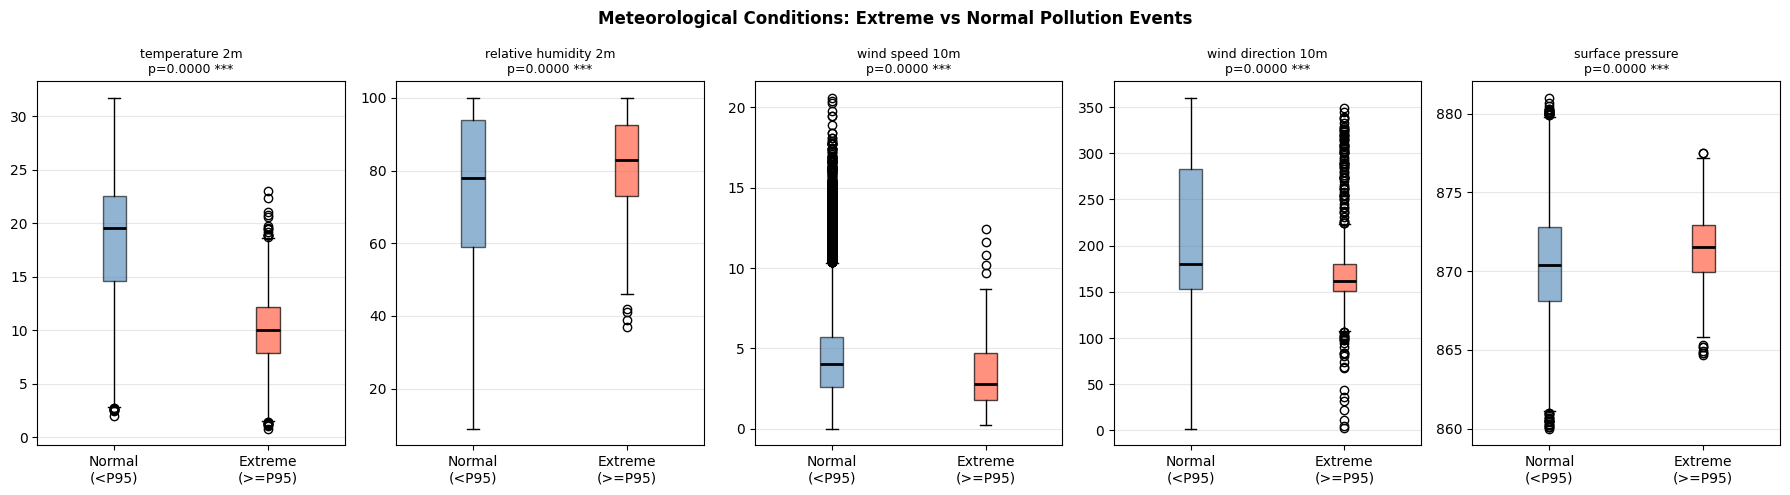

Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


In [60]:
# Meteorological conditions during extreme vs normal events — Mann-Whitney U test
normal  = data[data['pm2_5'] < p95]
extreme = extreme_95
met_features = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
                'wind_direction_10m', 'surface_pressure']

fig, axes = plt.subplots(1, len(met_features), figsize=(18, 5))
for i, feat in enumerate(met_features):
    bp = axes[i].boxplot(
        [normal[feat].values, extreme[feat].values],
        labels=['Normal\n(<P95)', 'Extreme\n(>=P95)'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set(facecolor='steelblue', alpha=0.6)
    bp['boxes'][1].set(facecolor='tomato', alpha=0.7)

    u_stat, p_val = stats.mannwhitneyu(normal[feat].dropna(), extreme[feat].dropna(),
                                        alternative='two-sided')
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    axes[i].set_title(f"{feat.replace('_', ' ')}\np={p_val:.4f} {sig}", fontsize=9)
    axes[i].grid(True, axis='y', alpha=0.3)

plt.suptitle('Meteorological Conditions: Extreme vs Normal Pollution Events', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

Co-pollutant Mean Concentrations: Normal vs Extreme PM2.5 Events
                  Normal (<P95)  Extreme (>=P95)  Ratio
pm10                      40.71           100.50   2.47
carbon_monoxide          572.86          1356.23   2.37
nitrogen_dioxide          11.65            30.01   2.58
sulphur_dioxide            5.60            16.32   2.92
ozone                     97.12            75.81   0.78


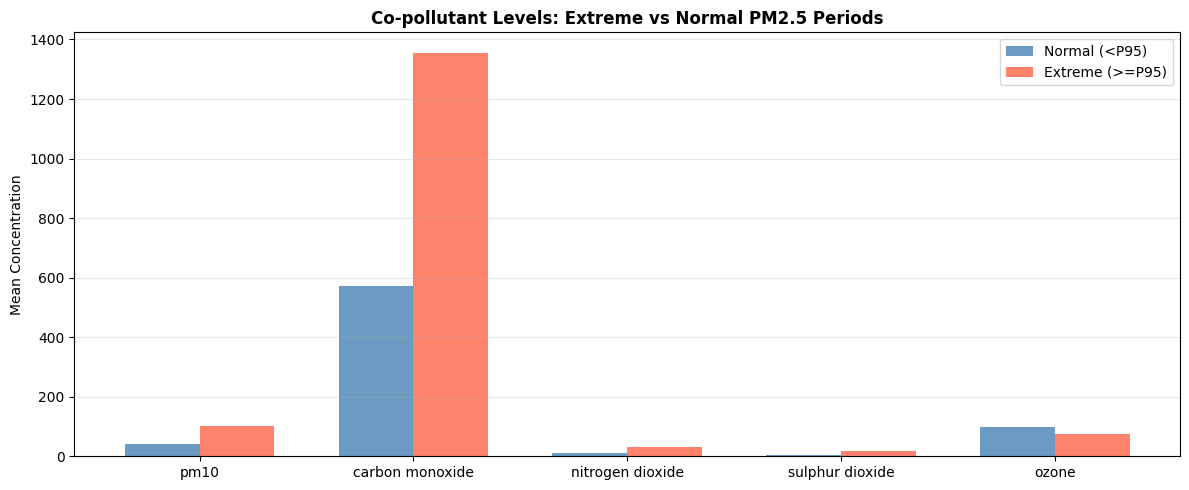

In [61]:
# Co-pollutant concentrations during extreme vs normal PM2.5 periods
copoll = ['pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

copoll_df = pd.DataFrame({
    'Normal (<P95)' : normal[copoll].mean(),
    'Extreme (>=P95)': extreme[copoll].mean()
})
copoll_df['Ratio'] = (copoll_df['Extreme (>=P95)'] / copoll_df['Normal (<P95)']).round(3)
print("Co-pollutant Mean Concentrations: Normal vs Extreme PM2.5 Events")
print(copoll_df.round(2).to_string())

x, w = np.arange(len(copoll)), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, copoll_df['Normal (<P95)'],  width=w, label='Normal (<P95)',   color='steelblue', alpha=0.8)
ax.bar(x + w/2, copoll_df['Extreme (>=P95)'], width=w, label='Extreme (>=P95)', color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in copoll], fontsize=10)
ax.set_title('Co-pollutant Levels: Extreme vs Normal PM2.5 Periods', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Concentration')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

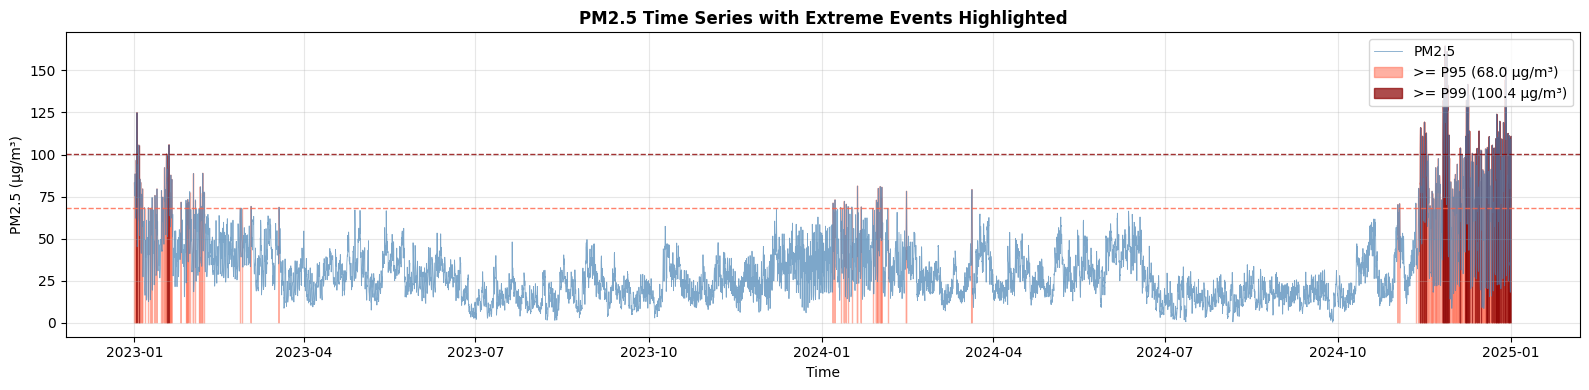

In [62]:
# Full timeline with extreme event highlighting
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(data['time'], data['pm2_5'], color='steelblue', linewidth=0.6, alpha=0.7, label='PM2.5')
ax.fill_between(data['time'], data['pm2_5'],
                where=(data['pm2_5'] >= p95), color='tomato',  alpha=0.5,
                label=f'>= P95 ({p95:.1f} µg/m³)')
ax.fill_between(data['time'], data['pm2_5'],
                where=(data['pm2_5'] >= p99), color='darkred', alpha=0.7,
                label=f'>= P99 ({p99:.1f} µg/m³)')
ax.axhline(p95, color='tomato',  linestyle='--', linewidth=1, alpha=0.8)
ax.axhline(p99, color='darkred', linestyle='--', linewidth=1, alpha=0.8)
ax.set_title('PM2.5 Time Series with Extreme Events Highlighted', fontsize=12, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 19. Feature Importance Pre-Analysis

In [63]:
# X_train_tree contains unscaled numeric features — no preprocessing needed.
# We explicitly DROP pm2_5 and pm10 (current-hour readings) from the feature set
# before importance analysis. These columns are near-duplicates of the target
# and dominate every importance metric, drowning out all other signals.
# The lag features (pm2_5_lag_1 ... pm2_5_lag_12) are the legitimate representation
# of past PM2.5 that a real forecasting model would actually have at prediction time.
LEAKAGE_COLS = ['pm2_5', 'pm10']

X_train_num = X_train.select_dtypes(include=[np.number]).drop(
    columns=[c for c in LEAKAGE_COLS if c in X_train.columns]
)
X_test_num  = X_test.select_dtypes(include=[np.number]).drop(
    columns=[c for c in LEAKAGE_COLS if c in X_test.columns]
)

print(f"Dropped (current-hour leakage): {LEAKAGE_COLS}")
print(f"Features remaining: {X_train_num.shape[1]}")
print(f"Columns: {list(X_train_num.columns)}")

Dropped (current-hour leakage): ['pm2_5', 'pm10']
Features remaining: 49
Columns: ['carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_4', 'pm2_5_lag_5', 'pm2_5_lag_6', 'pm2_5_lag_7', 'pm2_5_lag_8', 'pm2_5_lag_9', 'pm2_5_lag_10', 'pm2_5_lag_11', 'pm2_5_lag_12', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'carbon_monoxide_lag_1', 'carbon_monoxide_lag_2', 'carbon_monoxide_lag_3', 'nitrogen_dioxide_lag_1', 'nitrogen_dioxide_lag_2', 'nitrogen_dioxide_lag_3', 'sulphur_dioxide_lag_1', 'sulphur_dioxide_lag_2', 'sulphur_dioxide_lag_3', 'ozone_lag_1', 'ozone_lag_2', 'ozone_lag_3', 'temperature_2m_lag_1', 'relative_humidity_2m_lag_1', 'wind_speed_10m_lag_1', 'surface_pressure_lag_1', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'wind_dir_sin', 'wind_dir_cos', 'wind_dir_lag_1_sin', 'wind_dir_lag_1_cos']


In [64]:
# Fit Random Forest on leakage-free feature set
# With pm2_5 and pm10 removed, the model must learn from lag features,
# meteorological variables, and temporal encodings — the real forecasting signals.
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_num, y_train)
print("Random Forest fitted on leakage-free features.")

rf_imp = pd.Series(rf.feature_importances_, index=X_train_num.columns).sort_values(ascending=False)
print("\nTop 15 features by RF impurity importance (pm2_5 and pm10 excluded):")
print(rf_imp.head(15).to_string())

Random Forest fitted on leakage-free features.

Top 15 features by RF impurity importance (pm2_5 and pm10 excluded):
pm2_5_lag_1             0.857082
hour_sin                0.041154
pm10_lag_1              0.026795
hour_cos                0.009036
wind_dir_sin            0.005677
temperature_2m          0.005579
carbon_monoxide         0.004719
sulphur_dioxide         0.003672
pm10_lag_3              0.003165
ozone_lag_3             0.002999
pm2_5_lag_10            0.002914
temperature_2m_lag_1    0.002564
pm2_5_lag_12            0.002075
pm2_5_lag_11            0.001850
pm2_5_lag_9             0.001726


In [65]:
# Permutation importance on test set (model-agnostic, avoids impurity bias towards high-cardinality)
perm = permutation_importance(rf, X_test_num, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature' : X_train_num.columns,
    'perm_mean': perm.importances_mean,
    'perm_std' : perm.importances_std
}).sort_values('perm_mean', ascending=False).reset_index(drop=True)

print("Top 15 features by Permutation Importance (test set):")
print(perm_df.head(15).to_string(index=False))

Top 15 features by Permutation Importance (test set):
             feature  perm_mean  perm_std
         pm2_5_lag_1   1.161515  0.024226
            hour_cos   0.070106  0.003684
            hour_sin   0.038310  0.001690
      temperature_2m   0.017459  0.001042
          pm10_lag_1   0.016321  0.000292
        pm2_5_lag_12   0.004691  0.000266
relative_humidity_2m   0.004419  0.000266
        wind_dir_sin   0.004413  0.000365
     carbon_monoxide   0.003670  0.000201
        pm2_5_lag_11   0.002438  0.000101
        pm2_5_lag_10   0.002082  0.000188
          pm10_lag_3   0.001787  0.000116
         pm2_5_lag_2   0.001616  0.000059
temperature_2m_lag_1   0.001478  0.000136
         ozone_lag_3   0.001453  0.000100


In [66]:
# Pearson and Spearman correlations with PM2.5 target
corr_rows = []
for col in X_train_num.columns:
    r_p, p_p = stats.pearsonr(X_train_num[col], y_train)
    r_s, p_s = stats.spearmanr(X_train_num[col], y_train)
    corr_rows.append({'feature': col,
                      'pearson_r': round(r_p, 4), 'pearson_p': round(p_p, 6),
                      'spearman_r': round(r_s, 4), 'spearman_p': round(p_s, 6)})

corr_df = pd.DataFrame(corr_rows)
corr_df['abs_spearman'] = corr_df['spearman_r'].abs()
corr_df = corr_df.sort_values('abs_spearman', ascending=False).reset_index(drop=True)

print("Top 15 features by |Spearman r| with PM2.5 target:")
print(corr_df[['feature','pearson_r','spearman_r','pearson_p','spearman_p']].head(15).to_string(index=False))

Top 15 features by |Spearman r| with PM2.5 target:
     feature  pearson_r  spearman_r  pearson_p  spearman_p
 pm2_5_lag_1     0.9085      0.9156        0.0         0.0
  pm10_lag_1     0.8985      0.9080        0.0         0.0
 pm2_5_lag_2     0.8513      0.8604        0.0         0.0
  pm10_lag_2     0.8453      0.8563        0.0         0.0
 pm2_5_lag_3     0.7967      0.8084        0.0         0.0
  pm10_lag_3     0.7948      0.8083        0.0         0.0
 pm2_5_lag_4     0.7473      0.7612        0.0         0.0
 pm2_5_lag_5     0.7049      0.7204        0.0         0.0
 pm2_5_lag_6     0.6708      0.6870        0.0         0.0
 pm2_5_lag_7     0.6452      0.6618        0.0         0.0
 pm2_5_lag_8     0.6266      0.6449        0.0         0.0
 pm2_5_lag_9     0.6146      0.6360        0.0         0.0
pm2_5_lag_10     0.6046      0.6296        0.0         0.0
pm2_5_lag_11     0.5961      0.6227        0.0         0.0
pm2_5_lag_12     0.5906      0.6160        0.0         0.0


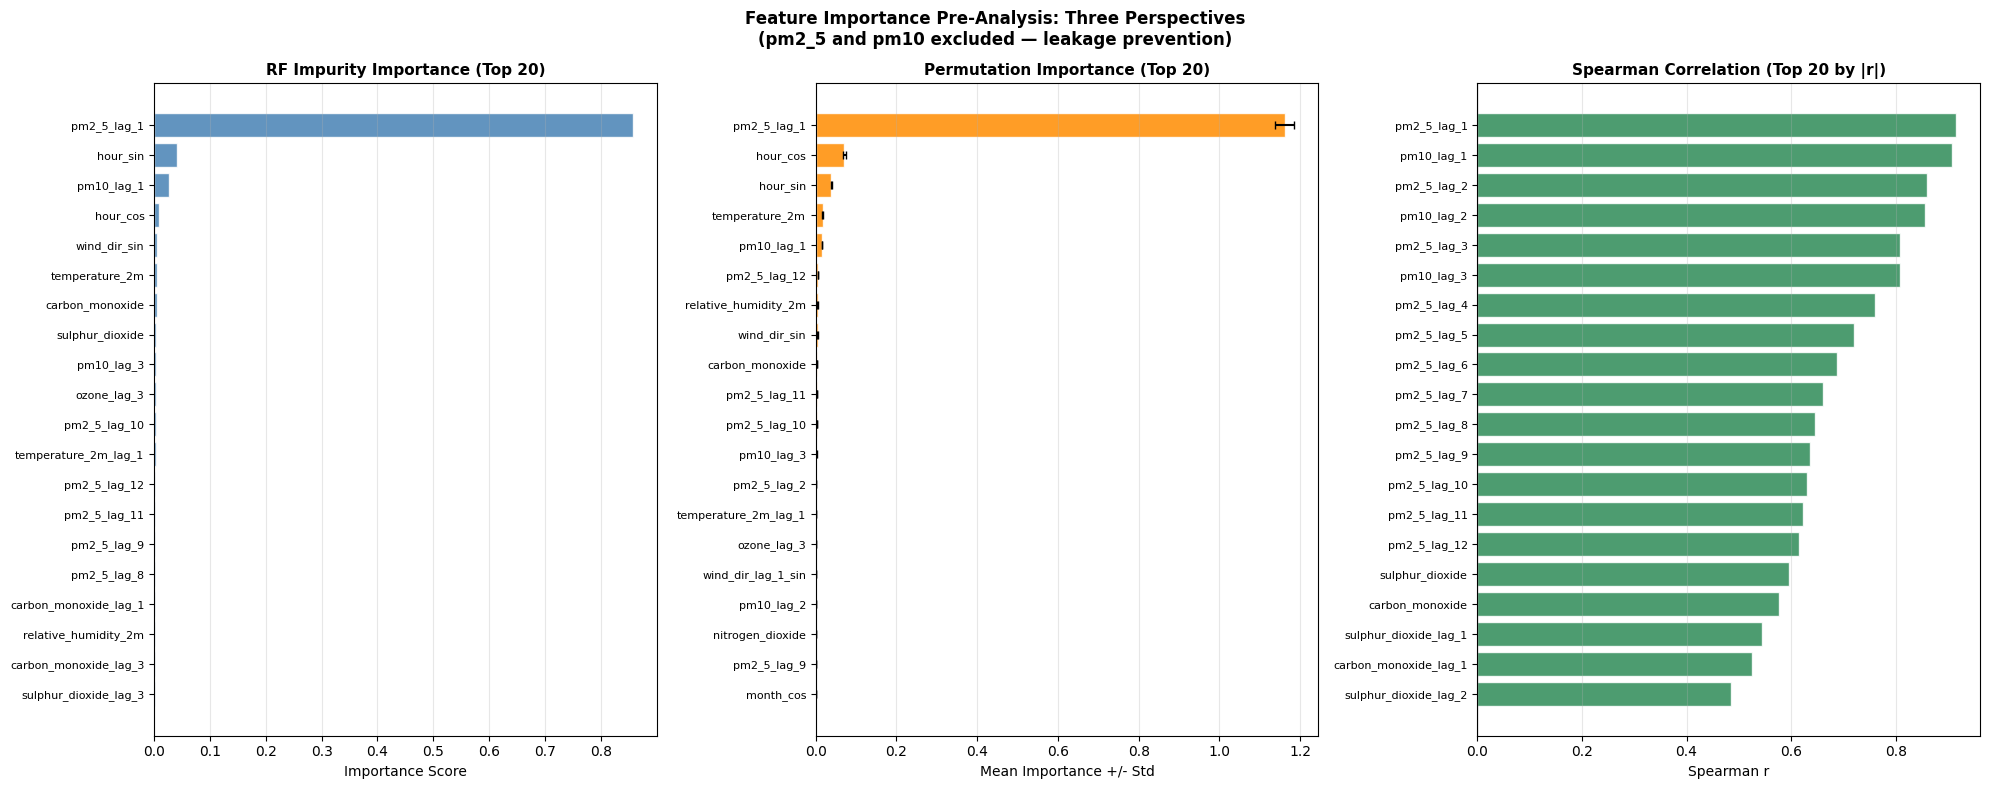

In [67]:
# Consolidated three-panel importance chart
top_n = min(20, len(rf_imp))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# RF Impurity
top_rf = rf_imp.head(top_n)
axes[0].barh(top_rf.index[::-1], top_rf.values[::-1], color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title(f'RF Impurity Importance (Top {top_n})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].grid(True, axis='x', alpha=0.3)

# Permutation Importance
top_perm = perm_df.head(top_n)
axes[1].barh(top_perm['feature'][::-1], top_perm['perm_mean'][::-1],
             xerr=top_perm['perm_std'][::-1], color='darkorange', alpha=0.85,
             ecolor='black', capsize=3, edgecolor='white')
axes[1].set_title(f'Permutation Importance (Top {top_n})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Importance +/- Std')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(True, axis='x', alpha=0.3)

# Spearman Correlation
top_sp = corr_df.head(top_n)
sp_colors = ['tomato' if r < 0 else 'seagreen' for r in top_sp['spearman_r'][::-1]]
axes[2].barh(top_sp['feature'][::-1], top_sp['spearman_r'][::-1],
             color=sp_colors, alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title(f'Spearman Correlation (Top {top_n} by |r|)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Spearman r')
axes[2].tick_params(axis='y', labelsize=8)
axes[2].grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance Pre-Analysis: Three Perspectives\n(pm2_5 and pm10 excluded — leakage prevention)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
# Rank agreement: RF vs Permutation vs Spearman
rf_ranked = rf_imp.reset_index()
rf_ranked.columns = ['feature', 'rf_imp']
rf_ranked['rf_rank'] = range(1, len(rf_ranked) + 1)

perm_ranked = perm_df[['feature', 'perm_mean']].copy()
perm_ranked['perm_rank'] = range(1, len(perm_ranked) + 1)

corr_ranked = corr_df[['feature','abs_spearman']].copy()
corr_ranked['corr_rank'] = range(1, len(corr_ranked) + 1)

rank_df = rf_ranked.merge(perm_ranked, on='feature').merge(corr_ranked, on='feature')
rank_df['mean_rank']      = (rank_df['rf_rank'] + rank_df['perm_rank'] + rank_df['corr_rank']) / 3
rank_df['rank_agreement'] = rank_df[['rf_rank','perm_rank','corr_rank']].std(axis=1).round(2)
rank_df = rank_df.sort_values('mean_rank')

print("Feature Rank Comparison (lower mean_rank = more important; lower rank_agreement = more consistent):")
print(rank_df[['feature','rf_rank','perm_rank','corr_rank','mean_rank','rank_agreement']].head(20).to_string(index=False))

Feature Rank Comparison (lower mean_rank = more important; lower rank_agreement = more consistent):
              feature  rf_rank  perm_rank  corr_rank  mean_rank  rank_agreement
          pm2_5_lag_1        1          1          1   1.000000            0.00
           pm10_lag_1        3          5          2   3.333333            1.53
           pm10_lag_3        9         12          6   9.000000            3.00
       temperature_2m        6          4         22  10.666667            9.87
      carbon_monoxide        7          9         17  11.000000            5.29
         pm2_5_lag_12       13          6         15  11.333333            4.73
         pm2_5_lag_10       11         11         13  11.666667            1.15
          pm2_5_lag_2       21         13          3  12.333333            9.02
         pm2_5_lag_11       14         10         14  12.666667            2.31
             hour_cos        4          2         33  13.000000           17.35
             hour_si

### 20. SHAP / Explainability Readiness Analysis

In [69]:
# Check if shap is installed
try:
    import shap
    SHAP_AVAILABLE = True
    print("shap library found. Full SHAP analysis will run.")
except ImportError:
    SHAP_AVAILABLE = False
    print("shap NOT installed. Run:  pip install shap")
    print("Proceeding with Partial Dependence Plots as explainability proxy.")

shap library found. Full SHAP analysis will run.


In [70]:
if SHAP_AVAILABLE:
    sample_size = min(300, len(X_test_num))
    X_sample    = X_test_num.sample(n=sample_size, random_state=42)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)
    print(f"SHAP values computed for {sample_size} test samples, shape: {shap_values.shape}")

    mean_shap   = np.abs(shap_values).mean(axis=0)
    shap_imp    = pd.Series(mean_shap, index=X_train_num.columns).sort_values(ascending=False)
    print("\nTop 15 features by mean |SHAP|:")
    print(shap_imp.head(15).to_string())

SHAP values computed for 300 test samples, shape: (300, 49)

Top 15 features by mean |SHAP|:
pm2_5_lag_1              16.433898
hour_sin                  2.193806
pm10_lag_1                0.760212
hour_cos                  0.627413
temperature_2m            0.354339
ozone_lag_3               0.280667
wind_dir_sin              0.218774
pm10_lag_3                0.218360
carbon_monoxide           0.168799
pm2_5_lag_10              0.166385
sulphur_dioxide_lag_3     0.142954
pm2_5_lag_12              0.134216
sulphur_dioxide           0.131101
pm2_5_lag_9               0.105663
pm2_5_lag_11              0.087805


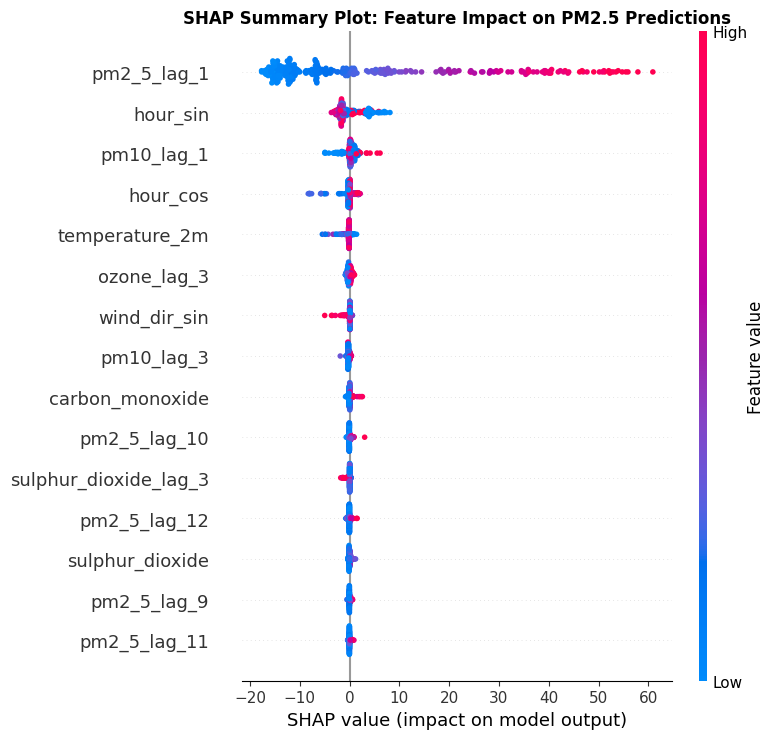

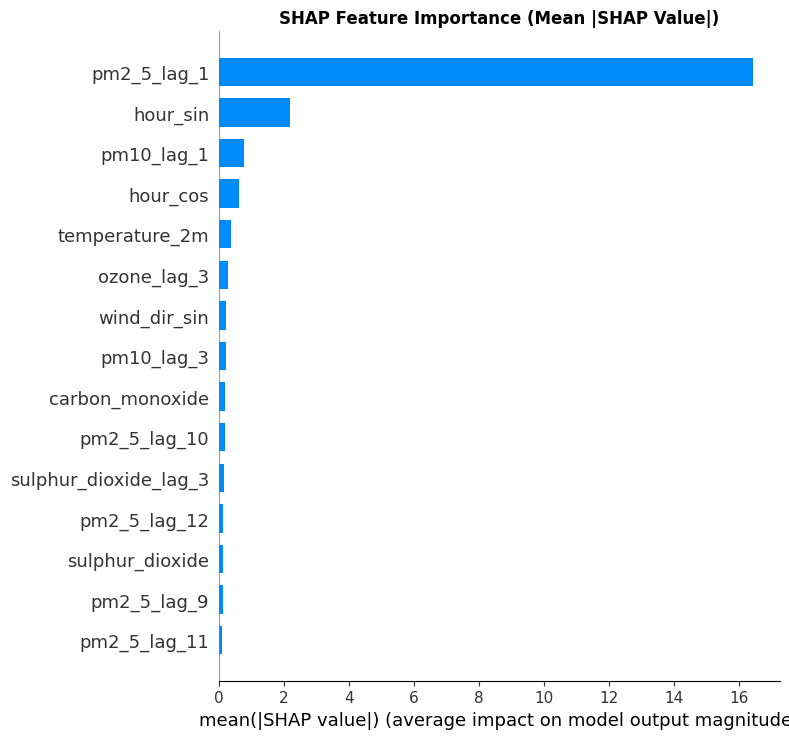

In [71]:
if SHAP_AVAILABLE:
    # SHAP Beeswarm Summary Plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15, plot_type='dot')
    plt.title('SHAP Summary Plot: Feature Impact on PM2.5 Predictions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # SHAP Bar Chart
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15, plot_type='bar')
    plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

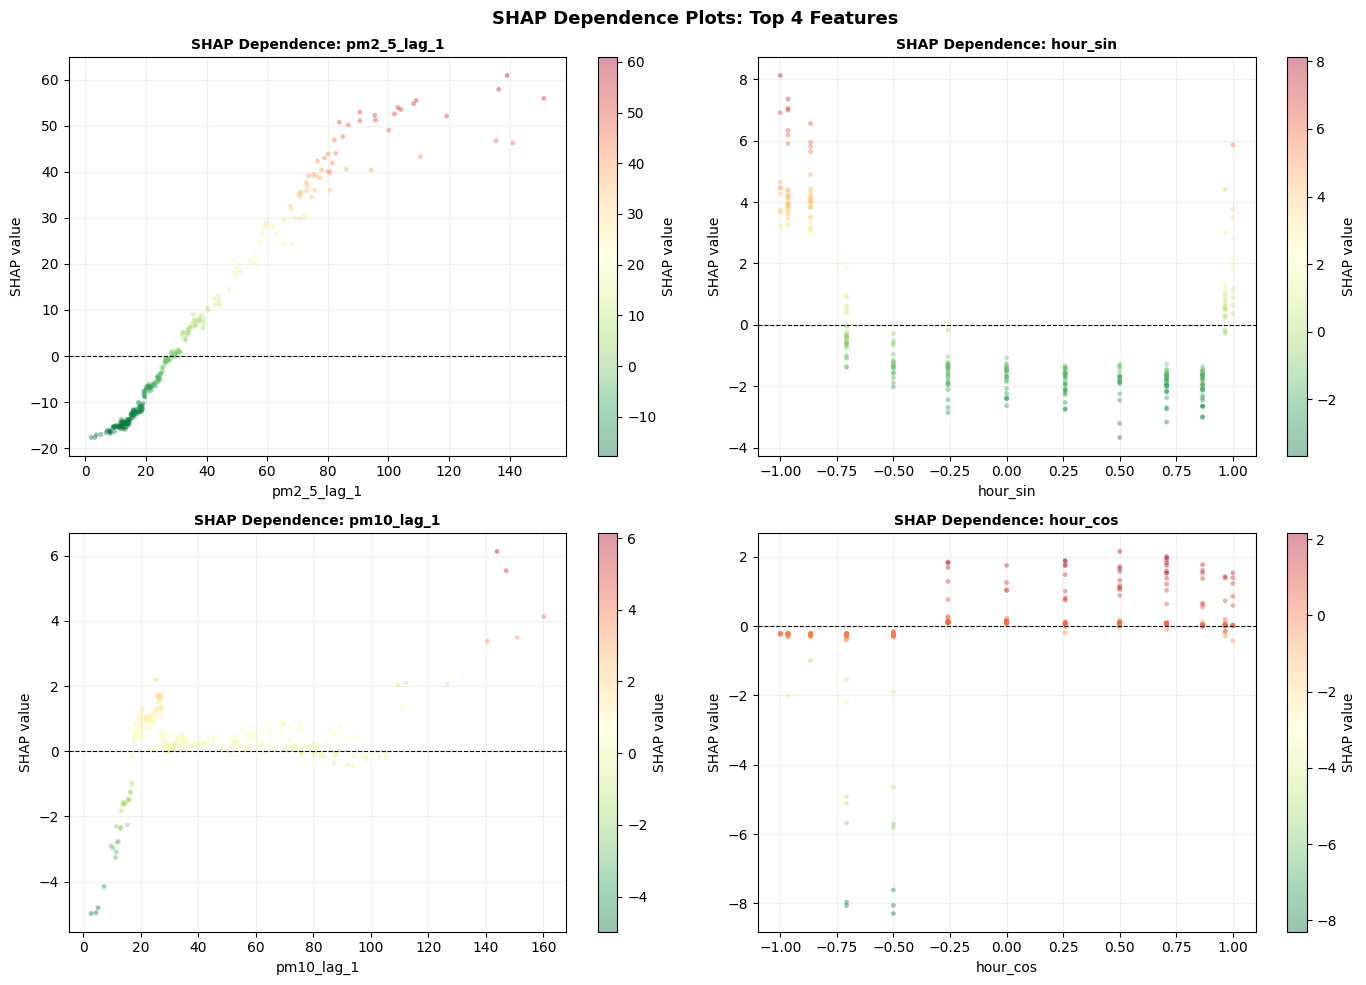

In [72]:
if SHAP_AVAILABLE:
    # SHAP Dependence Plots for top 4 features
    top4_shap = shap_imp.index[:4].tolist()
    feat_list = list(X_train_num.columns)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feat in enumerate(top4_shap):
        feat_idx  = feat_list.index(feat)
        sc = axes[i].scatter(
            X_sample[feat].values, shap_values[:, feat_idx],
            c=shap_values[:, feat_idx], cmap='RdYlGn_r', alpha=0.4, s=12, edgecolors='none'
        )
        plt.colorbar(sc, ax=axes[i], label='SHAP value')
        axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=10, fontweight='bold')
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('SHAP value')
        axes[i].grid(True, alpha=0.2)

    plt.suptitle('SHAP Dependence Plots: Top 4 Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

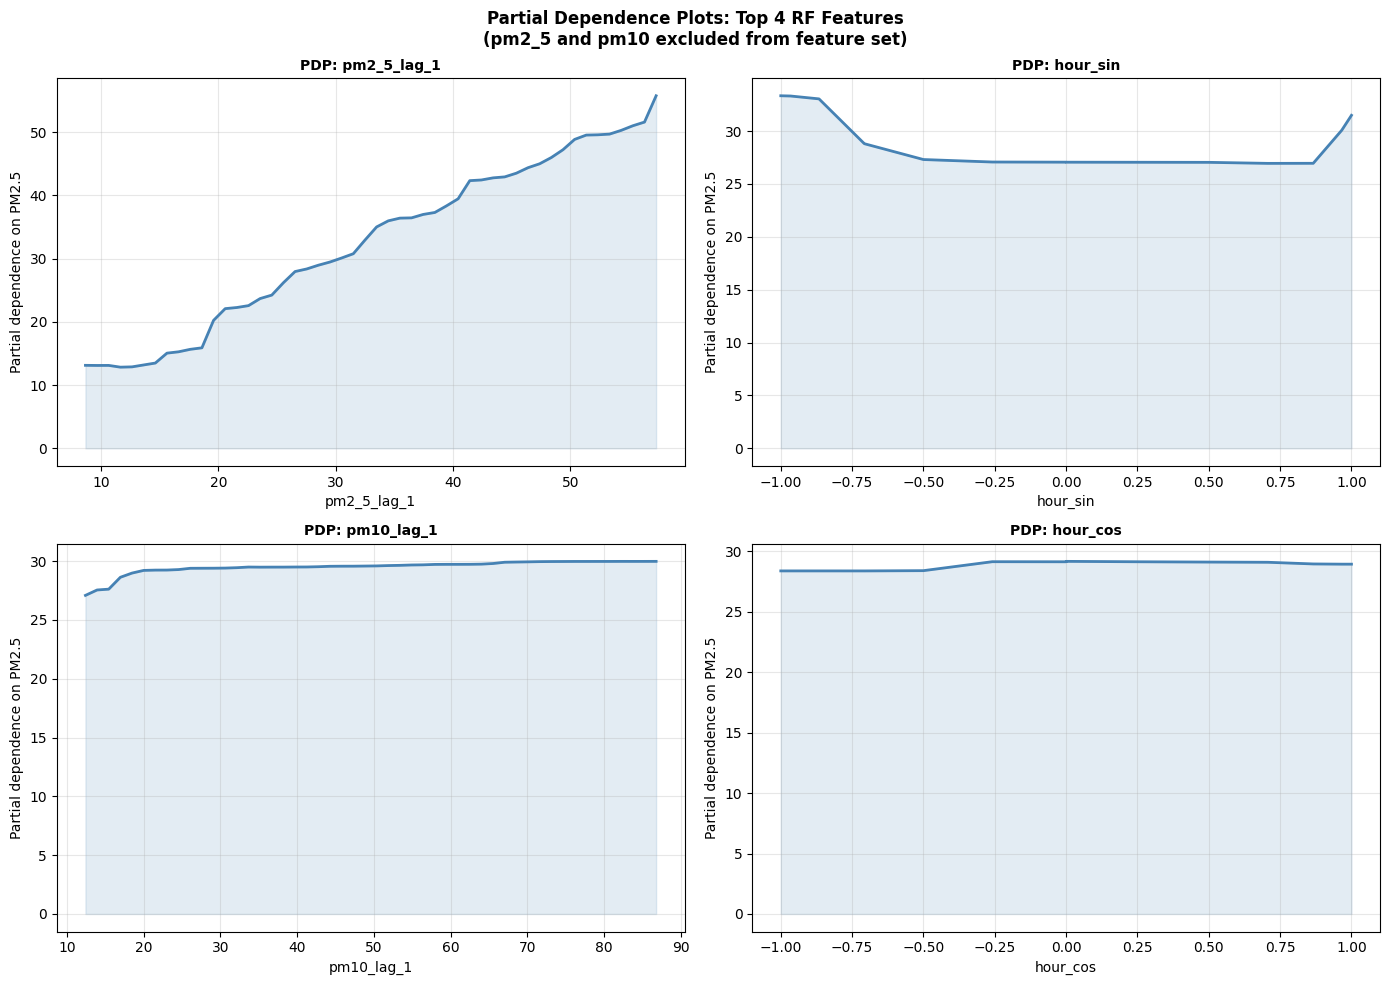

In [73]:
# Partial Dependence Plots — useful with or without SHAP
# Shows marginal effect of each top feature on PM2.5 predictions
top4_rf  = rf_imp.index[:4].tolist()
top4_idx = [list(X_train_num.columns).index(f) for f in top4_rf]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, fidx) in enumerate(zip(top4_rf, top4_idx)):
    pd_result = partial_dependence(rf, X_train_num, features=[fidx],
                                   kind='average', grid_resolution=50)
    grid = pd_result['grid_values'][0]
    avg  = pd_result['average'][0]

    axes[i].plot(grid, avg, color='steelblue', linewidth=2)
    axes[i].fill_between(grid, avg, alpha=0.15, color='steelblue')
    axes[i].set_title(f'PDP: {feat}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Partial dependence on PM2.5')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Partial Dependence Plots: Top 4 RF Features\n(pm2_5 and pm10 excluded from feature set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

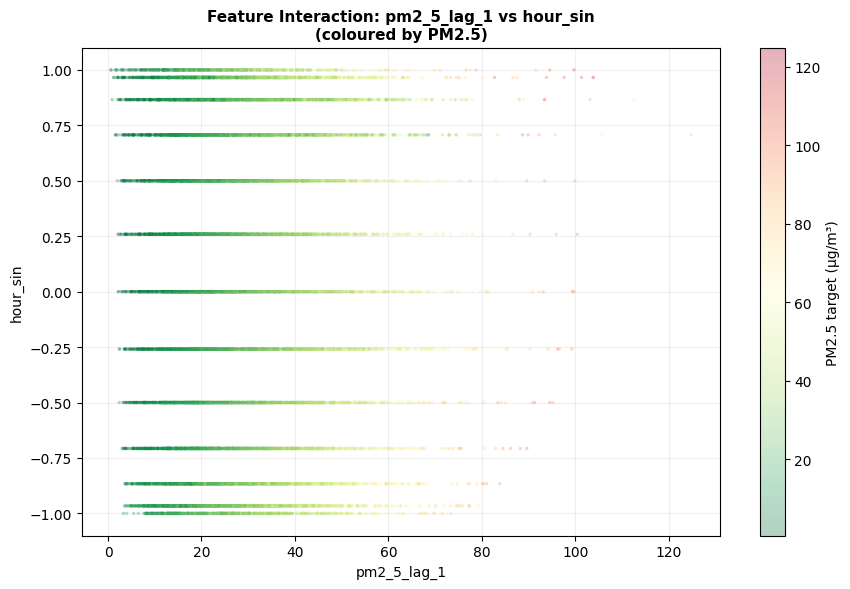

In [74]:
# Interaction scatter: top 2 features coloured by PM2.5 target value
f1 = rf_imp.index[0]
f2 = rf_imp.index[1]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_train_num[f1], X_train_num[f2],
                c=y_train.values, cmap='RdYlGn_r', alpha=0.3, s=6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='PM2.5 target (µg/m³)')
ax.set_title(f'Feature Interaction: {f1} vs {f2}\n(coloured by PM2.5)', fontsize=11, fontweight='bold')
ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [75]:
# Explainability Readiness Summary
print("=" * 58)
print("       SHAP / EXPLAINABILITY READINESS SUMMARY")
print("=" * 58)

print(f"\n1. SHAP available             : {SHAP_AVAILABLE}")
if not SHAP_AVAILABLE:
    print("   -> Install: pip install shap")

print(f"\n2. Top feature (RF impurity)  : {rf_imp.index[0]}")
print(f"   Top feature (Permutation)  : {perm_df.iloc[0]['feature']}")
if SHAP_AVAILABLE:
    print(f"   Top feature (SHAP)         : {shap_imp.index[0]}")

agree = rf_imp.index[0] == perm_df.iloc[0]['feature']
print(f"\n3. RF & Permutation agree #1  : {agree}")

# Features where methods strongly disagree (rank diff > 10)
disagreed = rank_df[rank_df['rank_agreement'] > 10][['feature','rf_rank','perm_rank','corr_rank']]
print(f"\n4. Features with high rank disagreement (std > 10): {len(disagreed)}")
if len(disagreed) > 0:
    print(disagreed.to_string(index=False))

print("\n5. Partial Dependence Plots   : computed above (sklearn)")
print("   Interaction scatter         : computed above")

print("\n5b. Leakage prevention")
print("   Dropped from analysis : pm2_5, pm10 (current-hour values)")
print("   Reason                : Near-duplicates of target; dominate importance metrics")
print("   Legitimate equivalent : pm2_5_lag_1, pm10_lag_1 (past values, forecasting-safe)")
print()
print("\n6. Next steps for full explainability:")
print("   - Run SHAP TreeExplainer on your final trained model (XGBoost / RF)")
print("   - Generate SHAP beeswarm + dependence plots for top 10 features")
print("   - Use X_test_tree (unscaled) for interpretable SHAP axis values")
print("   - Report permutation importance as model-agnostic cross-check")
print("   - Flag lag features with rank disagreement > 5 between RF & permutation")
print("=" * 58)

       SHAP / EXPLAINABILITY READINESS SUMMARY

1. SHAP available             : True

2. Top feature (RF impurity)  : pm2_5_lag_1
   Top feature (Permutation)  : pm2_5_lag_1
   Top feature (SHAP)         : pm2_5_lag_1

3. RF & Permutation agree #1  : True

4. Features with high rank disagreement (std > 10): 20
                   feature  rf_rank  perm_rank  corr_rank
                  hour_cos        4          2         33
                  hour_sin        2          3         39
                pm10_lag_2       25         17          4
               ozone_lag_3       10         15         32
           sulphur_dioxide        8         34         16
              wind_dir_sin        5          8         49
      relative_humidity_2m       18          7         45
               pm2_5_lag_8       16         44         11
               pm2_5_lag_3       29         39          5
     sulphur_dioxide_lag_1       40         21         18
               pm2_5_lag_4       32         42    